Sel 1 — Mount Google Drive & Install Library

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install scikit-image scikit-learn opencv-python lime tqdm -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Sel 2 — Import Library

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (GridSearchCV, learning_curve, cross_val_score, StratifiedKFold)
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix)
from lime import lime_image
from skimage.segmentation import mark_boundaries
import joblib

Sel 3 — Konfigurasi Path & Parameter

In [4]:
BASE_DIR   = Path("/content/drive/MyDrive/Pothole_Classification_Project")
TRAIN_DIR  = BASE_DIR / "dataset/2_processed/train"
TEST_DIR   = BASE_DIR / "dataset/2_processed/test"
MODEL_DIR  = BASE_DIR / "saved_models"
OUTPUT_DIR = BASE_DIR / "outputs"

CLASSES    = ["berlubang", "mulus"]
HOG_SIZE   = (64, 64)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Konfigurasi siap.")

✅ Konfigurasi siap.


Sel 4 — Fungsi Ekstraksi HOG

In [5]:
def extract_hog_features(img_path, size=HOG_SIZE):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, size, interpolation=cv2.INTER_AREA)

    features = hog(
        img_resized,
        orientations    = 9,
        pixels_per_cell = (8, 8),
        cells_per_block = (2, 2),
        block_norm      = "L2-Hys",
        feature_vector  = True
    )
    return features

Sel 5 — Load & Ekstraksi Fitur Train Set

In [6]:
print("⚙️  Mengekstrak fitur HOG dari Train Set...\n")

X_train, y_train = [], []

for label_idx, cls in enumerate(CLASSES):
    paths = list((TRAIN_DIR / cls).glob("*.jpg"))
    for path in tqdm(paths, desc=f"[{cls}]"):
        feat = extract_hog_features(path)
        if feat is not None:
            X_train.append(feat)
            y_train.append(label_idx)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"\n✅ Train set siap.")
print(f"   Jumlah sampel : {X_train.shape[0]}")
print(f"   Panjang vektor: {X_train.shape[1]}")

⚙️  Mengekstrak fitur HOG dari Train Set...



[mulus]: 100%|██████████| 1540/1540 [00:50<00:00, 30.25it/s] 


✅ Train set siap.
   Jumlah sampel : 3080
   Panjang vektor: 1764


Sel 6 — Load & Ekstraksi Fitur Test Set

In [7]:
print("⚙️  Mengekstrak fitur HOG dari Test Set...\n")

X_test, y_test       = [], []
test_images_raw      = []

for label_idx, cls in enumerate(CLASSES):
    paths = list((TEST_DIR / cls).glob("*.jpg"))
    for path in tqdm(paths, desc=f"[{cls}]"):
        feat = extract_hog_features(path)
        if feat is not None:
            X_test.append(feat)
            y_test.append(label_idx)

            img     = cv2.imread(str(path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_res = cv2.resize(img_rgb, (224, 224))
            test_images_raw.append(img_res)

X_test          = np.array(X_test)
y_test          = np.array(y_test)
test_images_raw = np.array(test_images_raw)

print(f"\n✅ Test set siap.")
print(f"   Jumlah sampel : {X_test.shape[0]}")

⚙️  Mengekstrak fitur HOG dari Test Set...



[mulus]: 100%|██████████| 35/35 [00:09<00:00,  3.63it/s]


✅ Test set siap.
   Jumlah sampel : 70


Sel 7 — Normalisasi Fitur

In [8]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Fitur dinormalisasi dengan StandardScaler.")

✅ Fitur dinormalisasi dengan StandardScaler.


Sel 8 — Hyperparameter Tuning dan Training SVM

In [9]:
# print("🔍 Memulai Hyperparameter Tuning (GridSearchCV)...\n")

# param_grid = {
#     "C"      : [1, 10],
#     "kernel" : ["linear", "rbf"],
#     "gamma"  : ["scale"]
# }

# grid_search = GridSearchCV(
#     estimator  = SVC(probability=True, random_state=42),
#     param_grid = param_grid,
#     cv         = 5,
#     scoring    = "accuracy",
#     n_jobs     = -1,
#     verbose    = 2
# )

# grid_search.fit(X_train, y_train)

# print("\n✅ Tuning selesai!")
# print(f"   Best Params   : {grid_search.best_params_}")
# print(f"   Best CV Score : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

# svm_model = grid_search.best_estimator_

Sel 9 — Training SVM (Parameter Terbaik)

In [10]:
# Sel ini dibuat untuk mempercepat proses training, karena sebelumnya sudah dilakukan hyperparameter tuning
# Jadi tinggal menuliskan hasil parameter terbaik dari hyperparameter sebelumnya saja
print("🏋️  Melatih SVM dengan parameter terbaik...\n")

svm_model = SVC(
    C            = 10,
    kernel       = "rbf",
    gamma        = "scale",
    probability  = True,
    random_state = 42
)

svm_model.fit(X_train, y_train)
print("✅ Training selesai!")

🏋️  Melatih SVM dengan parameter terbaik...

✅ Training selesai!


Sel 10 — Evaluasi Model

In [11]:
y_pred = svm_model.predict(X_test)

acc  = accuracy_score (y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec  = recall_score   (y_test, y_pred, average="weighted")
f1   = f1_score       (y_test, y_pred, average="weighted")

print("=" * 45)
print("        HASIL EVALUASI — HOG + SVM")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=CLASSES))

        HASIL EVALUASI — HOG + SVM
  Accuracy  : 0.9429  (94.29%)
  Precision : 0.9429
  Recall    : 0.9429
  F1-Score  : 0.9429

Classification Report:

              precision    recall  f1-score   support

   berlubang       0.94      0.94      0.94        35
       mulus       0.94      0.94      0.94        35

    accuracy                           0.94        70
   macro avg       0.94      0.94      0.94        70
weighted avg       0.94      0.94      0.94        70



Sel 11 — Confusion Matrix

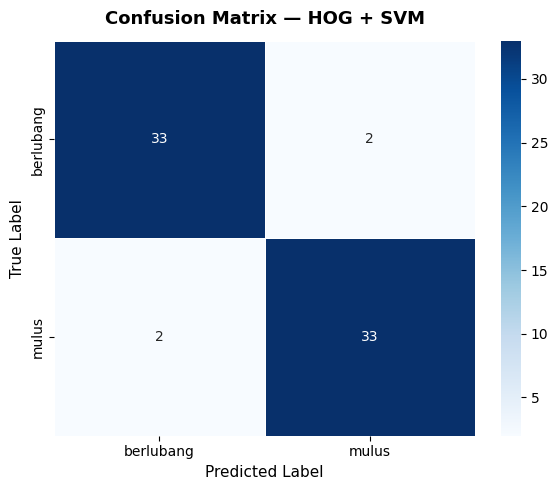

✅ Confusion matrix disimpan ke outputs/


In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix — HOG + SVM", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cm_hog_svm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix disimpan ke outputs/")

Sel 12 — Cross Validation Score

🔍 Menghitung Cross Validation Score...

  CV Scores per fold : ['0.9562', '0.9545', '0.9513', '0.9562', '0.9448']
  Mean CV Accuracy   : 0.9526 (95.26%)
  Std CV Accuracy    : 0.0043
  Test Accuracy      : 0.9429 (94.29%)
  Selisih CV vs Test : 0.0097


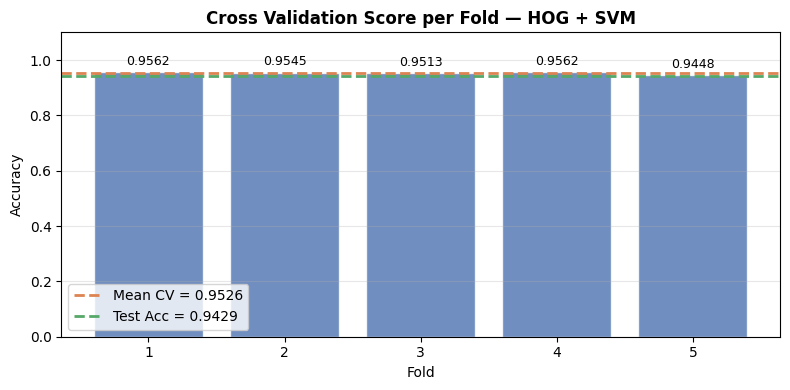

✅ CV scores disimpan ke outputs/


In [13]:
print("🔍 Menghitung Cross Validation Score...\n")

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(C=10, kernel="rbf", gamma="scale",
                   probability=True, random_state=42))
])

X_train_raw, y_train_raw = [], []
for label_idx, cls in enumerate(CLASSES):
    paths = list((TRAIN_DIR / cls).glob("*.jpg"))
    for path in paths:
        feat = extract_hog_features(path)
        if feat is not None:
            X_train_raw.append(feat)
            y_train_raw.append(label_idx)

X_train_raw = np.array(X_train_raw)
y_train_raw = np.array(y_train_raw)

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train_raw, y_train_raw,
                             cv=cv, scoring="accuracy", n_jobs=-1)

print(f"  CV Scores per fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean CV Accuracy   : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"  Std CV Accuracy    : {cv_scores.std():.4f}")
print(f"  Test Accuracy      : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Selisih CV vs Test : {abs(cv_scores.mean() - acc):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(1, 6), cv_scores, color="#4C72B0", alpha=0.8, edgecolor="white")
ax.axhline(cv_scores.mean(), color="#DD8452", linestyle="--",
           linewidth=2, label=f"Mean CV = {cv_scores.mean():.4f}")
ax.axhline(acc, color="#55A868", linestyle="--",
           linewidth=2, label=f"Test Acc = {acc:.4f}")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_title("Cross Validation Score per Fold — HOG + SVM", fontsize=12, fontweight="bold")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cv_scores_hog_svm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ CV scores disimpan ke outputs/")

Sel 13 — Diagnosis Otomatis

In [14]:
print("\n" + "=" * 50)
print("       DIAGNOSIS MODEL — HOG + SVM")
print("=" * 50)

cv_test_gap = abs(cv_scores.mean() - acc)

print(f"\n  Mean CV Accuracy   : {cv_scores.mean():.4f}")
print(f"  Test Accuracy      : {acc:.4f}")
print(f"  Std CV             : {cv_scores.std():.4f}")
print(f"  Gap CV vs Test     : {cv_test_gap:.4f}")

print("\n  📋 Kesimpulan:")

if cv_scores.mean() < 0.7 and acc < 0.7:
    print("  ⚠️  UNDERFITTING — Akurasi CV dan Test sama-sama rendah.")
    print("      Saran: tambah kompleksitas model atau perbaiki fitur.")

elif acc - cv_scores.mean() > 0.1:
    print("  ⚠️  OVERFITTING — Test accuracy jauh lebih tinggi dari CV.")
    print("      Model terlalu hafal data train.")
    print("      Saran: tambah regularisasi atau kurangi kompleksitas.")

elif cv_scores.mean() - acc > 0.1:
    print("  ⚠️  DISTRIBUSI TIDAK KONSISTEN — CV jauh lebih tinggi dari Test.")
    print("      Kemungkinan distribusi train dan test tidak seragam.")

elif cv_scores.std() > 0.05:
    print("  ⚠️  VARIANCE TINGGI — Performa tidak stabil antar fold.")
    print("      Model sensitif terhadap pembagian data.")

else:
    print("  ✅ MODEL SEHAT — Tidak terdeteksi overfitting maupun underfitting.")
    print(f"     Performa stabil dengan std CV = {cv_scores.std():.4f}")
    print(f"     Gap CV vs Test = {cv_test_gap:.4f} (dalam batas wajar)")

print("=" * 50)


       DIAGNOSIS MODEL — HOG + SVM

  Mean CV Accuracy   : 0.9526
  Test Accuracy      : 0.9429
  Std CV             : 0.0043
  Gap CV vs Test     : 0.0097

  📋 Kesimpulan:
  ✅ MODEL SEHAT — Tidak terdeteksi overfitting maupun underfitting.
     Performa stabil dengan std CV = 0.0043
     Gap CV vs Test = 0.0097 (dalam batas wajar)


Sel 14 — Visualisasi HOG

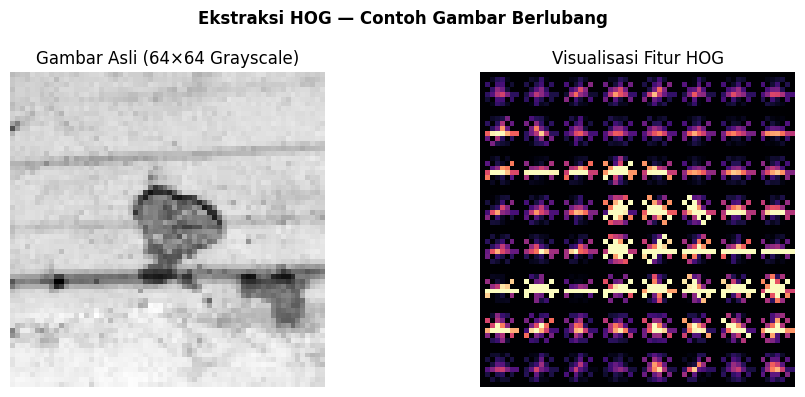

✅ Visualisasi HOG disimpan ke outputs/


In [15]:
sample_path = list((TEST_DIR / "berlubang").glob("*.jpg"))[0]
img_orig    = cv2.cvtColor(cv2.imread(str(sample_path)), cv2.COLOR_BGR2GRAY)
img_resized = cv2.resize(img_orig, HOG_SIZE, interpolation=cv2.INTER_AREA)

features, hog_image = hog(
    img_resized,
    orientations    = 9,
    pixels_per_cell = (8, 8),
    cells_per_block = (2, 2),
    block_norm      = "L2-Hys",
    visualize       = True,
    feature_vector  = True
)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_resized, cmap="gray")
axes[0].set_title("Gambar Asli (64×64 Grayscale)")
axes[0].axis("off")

axes[1].imshow(hog_image_rescaled, cmap="magma")
axes[1].set_title("Visualisasi Fitur HOG")
axes[1].axis("off")

plt.suptitle("Ekstraksi HOG — Contoh Gambar Berlubang", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hog_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisasi HOG disimpan ke outputs/")

Sel 16 — LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

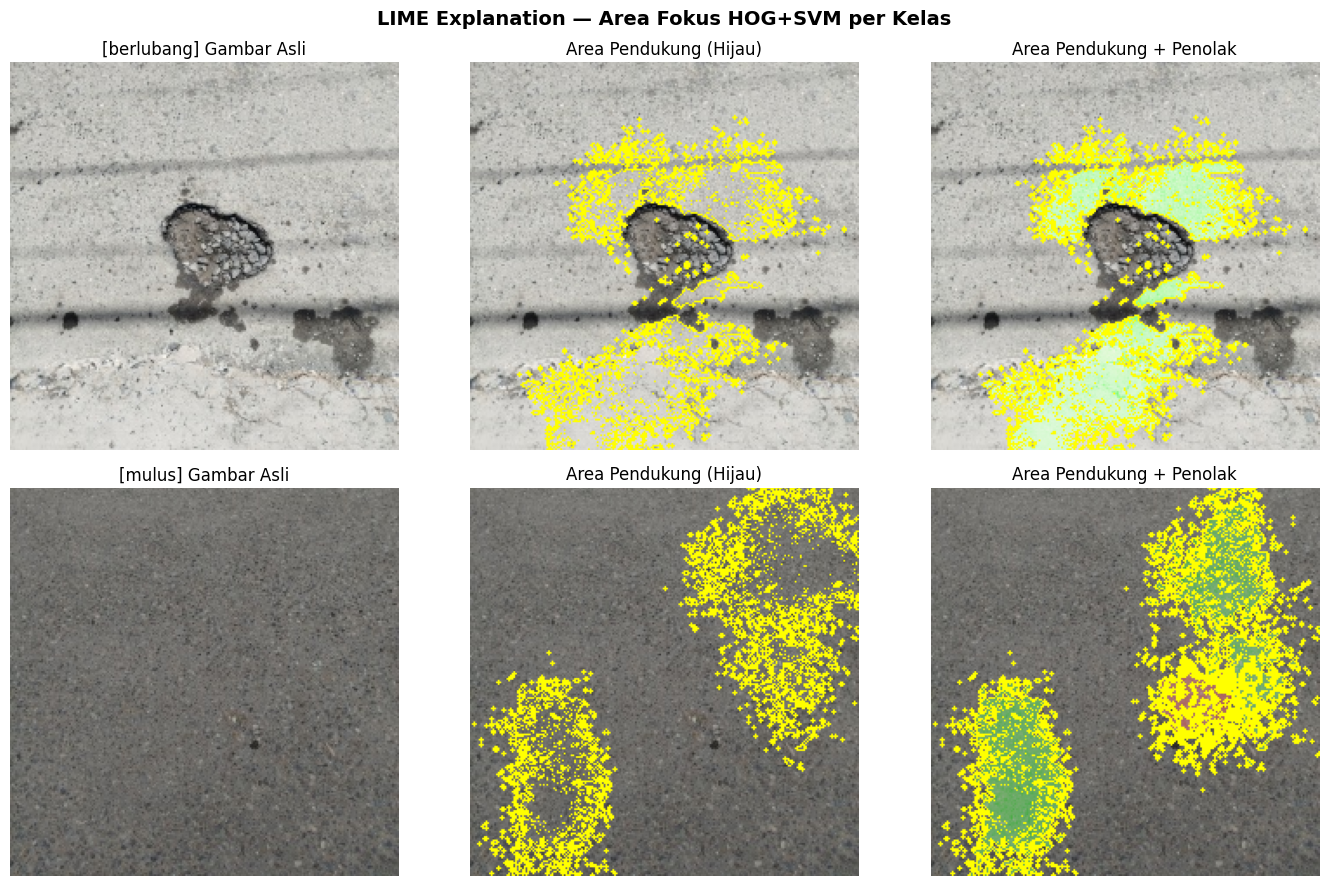

✅ Visualisasi LIME disimpan ke outputs/


In [16]:
def predict_fn_hog(images):
    batch = []
    for img in images:
        img_gray    = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        img_resized = cv2.resize(img_gray, HOG_SIZE)
        feat = hog(
            img_resized,
            orientations    = 9,
            pixels_per_cell = (8, 8),
            cells_per_block = (2, 2),
            block_norm      = "L2-Hys",
            feature_vector  = True
        )
        batch.append(feat)
    batch_scaled = scaler.transform(np.array(batch))
    return svm_model.predict_proba(batch_scaled)

explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("LIME Explanation — Area Fokus HOG+SVM per Kelas",
             fontsize=14, fontweight="bold")

sample_indices = {
    "berlubang": np.where(np.array(y_test) == 0)[0][0],
    "mulus"    : np.where(np.array(y_test) == 1)[0][0]
}

for row, (cls, idx) in enumerate(sample_indices.items()):
    img_display = test_images_raw[idx]

    explanation = explainer.explain_instance(
        img_display.astype(np.double),
        predict_fn_hog,
        top_labels  = 2,
        hide_color  = 0,
        num_samples = 1000
    )

    label_idx = 0 if cls == "berlubang" else 1

    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"[{cls}] Gambar Asli")
    axes[row, 0].axis("off")

    temp_pos, mask_pos = explanation.get_image_and_mask(
        label_idx, positive_only=True, num_features=5, hide_rest=False
    )
    axes[row, 1].imshow(mark_boundaries(temp_pos.astype(np.uint8), mask_pos))
    axes[row, 1].set_title("Area Pendukung (Hijau)")
    axes[row, 1].axis("off")

    temp_neg, mask_neg = explanation.get_image_and_mask(
        label_idx, positive_only=False, num_features=5, hide_rest=False
    )
    axes[row, 2].imshow(mark_boundaries(temp_neg.astype(np.uint8), mask_neg))
    axes[row, 2].set_title("Area Pendukung + Penolak")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lime_hog_svm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisasi LIME disimpan ke outputs/")

Sel 17 — Simpan Model

In [17]:
joblib.dump(svm_model, MODEL_DIR / "svm_hog_model.pkl")
joblib.dump(scaler,    MODEL_DIR / "scaler_hog.pkl")

print("✅ Model tersimpan:")
print(f"   → {MODEL_DIR / 'svm_hog_model.pkl'}")
print(f"   → {MODEL_DIR / 'scaler_hog.pkl'}")

✅ Model tersimpan:
   → /content/drive/MyDrive/Pothole_Classification_Project/saved_models/svm_hog_model.pkl
   → /content/drive/MyDrive/Pothole_Classification_Project/saved_models/scaler_hog.pkl
